device = cpu
Размер датасета: 4320 записей
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Пропуски: 0

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


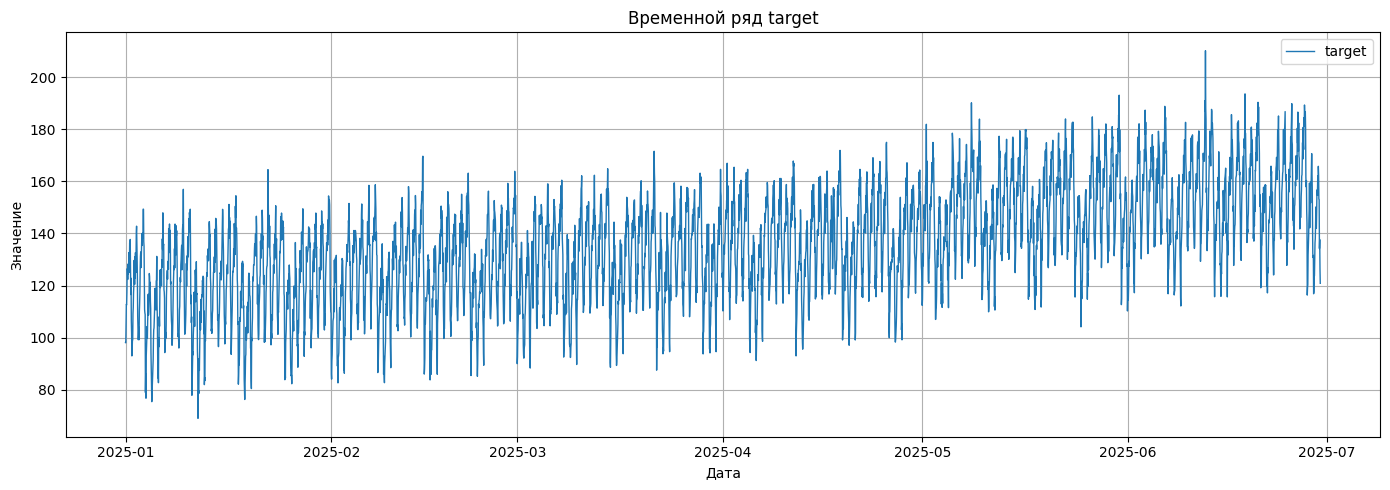


Комментарий к данным:
- Ряд имеет суточную частоту (24 наблюдения в день)
- Наблюдается дневная сезонность (дневные пики)
- Есть недельная сезонность (выходные ниже)
- Присутствуют выбросы (всплески)
- Данные стабильны, тренд слабо выражен
train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


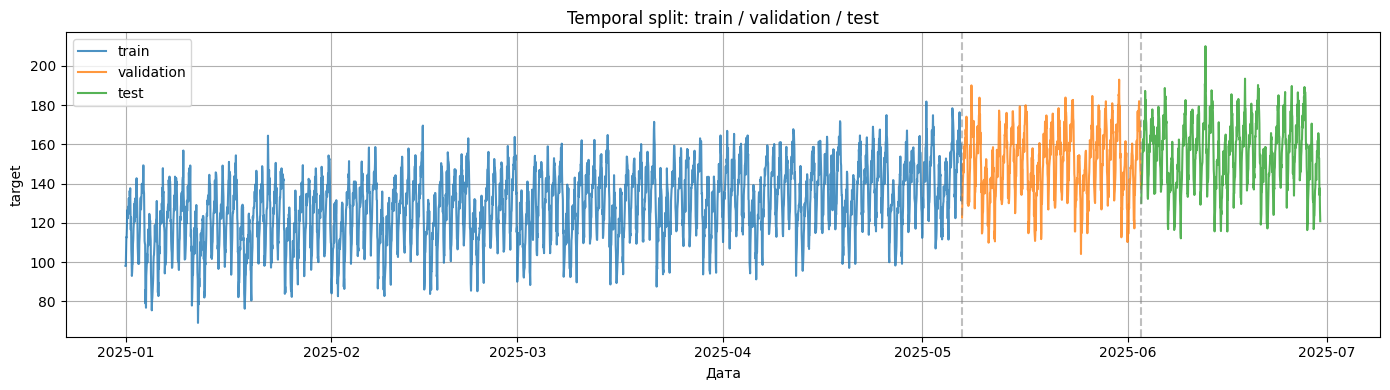


Почему random split некорректен?
При random split данные перемешиваются, и модель может 'подглядывать' в будущее.
В реальном прогнозировании мы предсказываем будущее на основе прошлого.
Temporal split сохраняет хронологический порядок, что соответствует реальной задаче.
После построения признаков: 4264 записей
X_train: (2984, 22), y_train: (2984,)
X_val:   (640, 22), y_val:   (640,)
X_test:  (640, 22), y_test:  (640,)

Результаты на validation:
           model       MAE      RMSE   MAPE_%
   Naive (lag_1)  6.452859  8.224114 4.403973
MovingAverage(7) 12.752272 15.280782 8.854030
           Ridge  5.124264  6.423036 3.418945


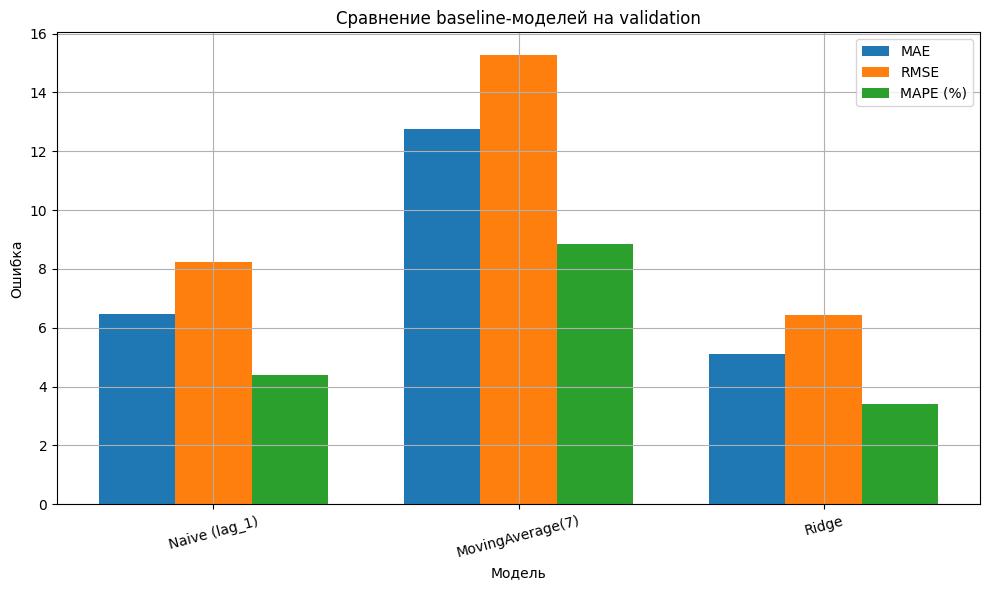

Train samples: 2960
Val samples: 616
Test samples: 616
Model parameters: 37889

Начало обучения GRU...
Epoch 10/50 | train_loss: 0.1048 | val_loss: 0.1589 | val_MAE: 5.7932
Epoch 20/50 | train_loss: 0.1016 | val_loss: 0.1430 | val_MAE: 5.4821
Epoch 30/50 | train_loss: 0.0959 | val_loss: 0.1407 | val_MAE: 5.4263
Epoch 40/50 | train_loss: 0.0910 | val_loss: 0.1340 | val_MAE: 5.2247
Epoch 50/50 | train_loss: 0.0883 | val_loss: 0.1333 | val_MAE: 5.1848

Обучение завершено. Лучшая val_MAE: 5.0212


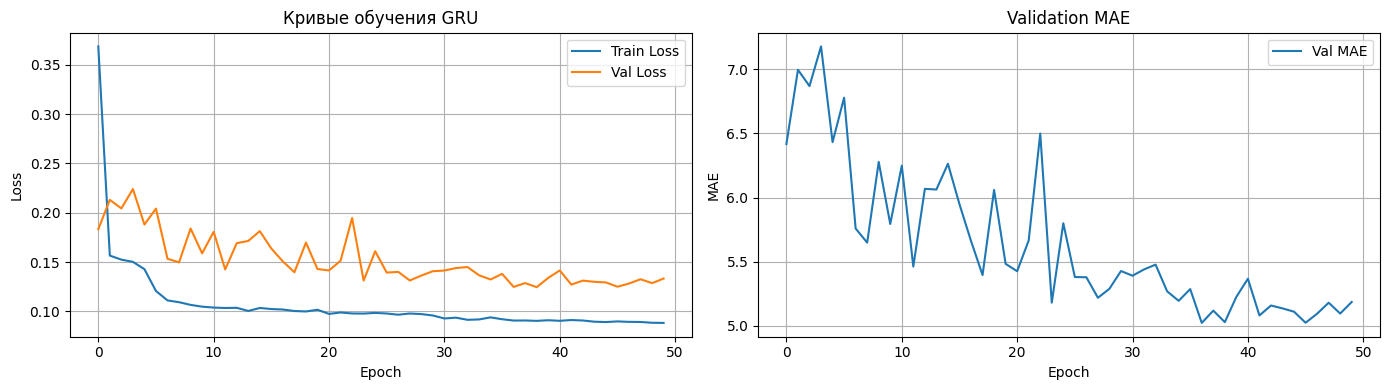


=== Финальные результаты на test ===
GRU - MAE: 5.6788, RMSE: 7.3231, MAPE: 3.6719%
Лучший baseline (Ridge) - MAE: 5.1243


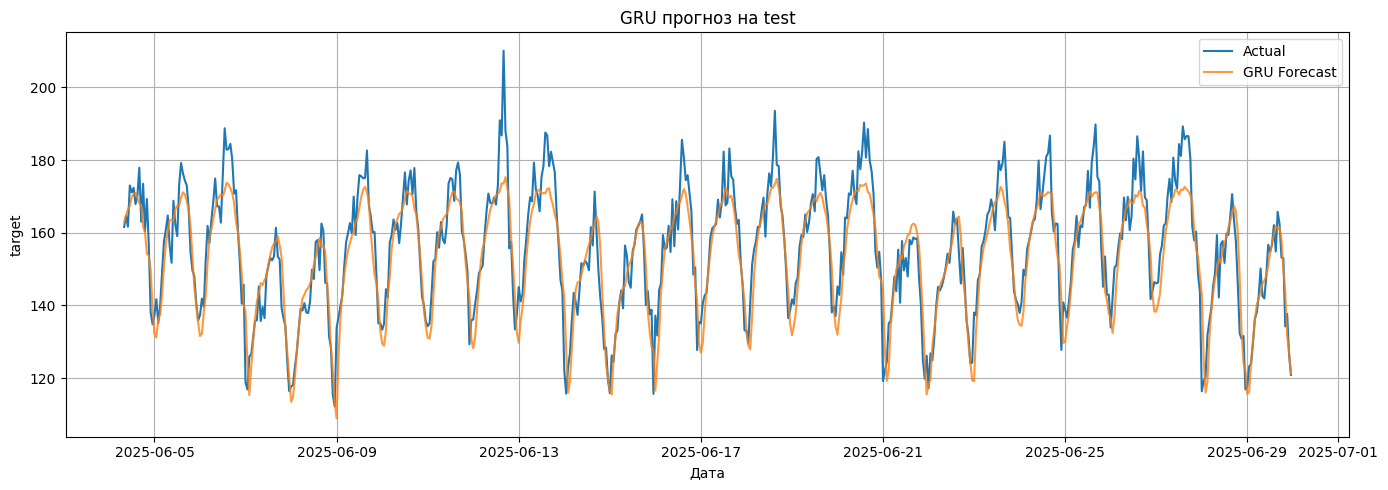


Результаты сохранены в artifacts/runs.csv

Топ-10 ошибок GRU на test:
               date     actual  prediction  abs_error
2025-06-12 16:00:00 210.100006  173.500153  36.599854
2025-06-28 00:00:00 116.379997  143.153458  26.773460
2025-06-21 00:00:00 119.180000  144.325729  25.145729
2025-06-09 00:00:00 133.850006  108.933319  24.916687
2025-06-16 00:00:00 137.199997  116.580154  20.619843
2025-06-18 15:00:00 193.540009  173.397552  20.142456
2025-06-14 00:00:00 122.040001  141.881287  19.841286
2025-06-12 14:00:00 190.949997  171.424393  19.525604
2025-06-07 00:00:00 118.820000  138.243729  19.423729
2025-06-23 00:00:00 138.039993  119.179634  18.860359


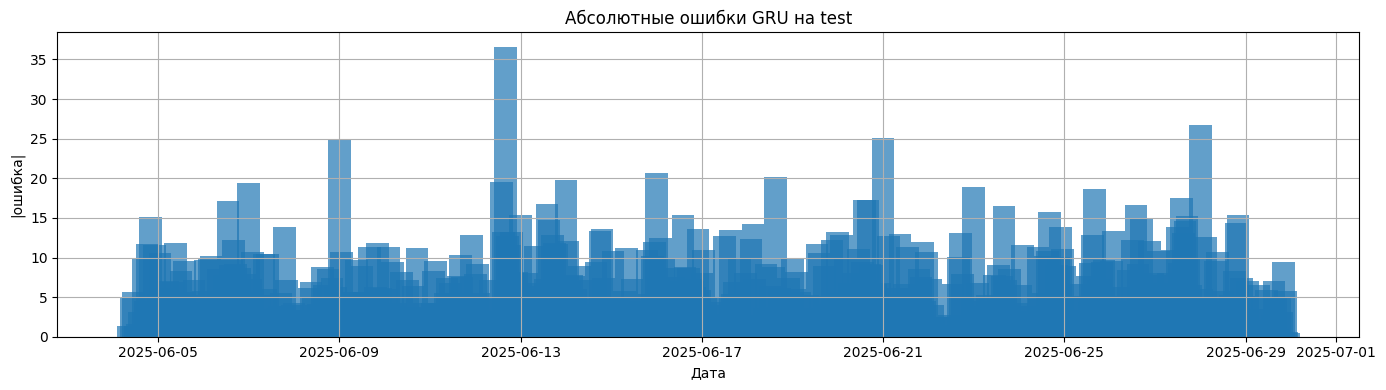


=== Итоговый вывод ===
Лучшая модель по validation: Ridge (MAE=5.0212)
GRU показал на test: MAE=5.6788
Лучший baseline (Ridge) на test: MAE=5.1243

Вывод: GRU не превзошёл Ridge на этом датасете.
Лаговые и rolling-признаки оказались достаточными для хорошего прогноза.
Для улучшения GRU требуется больше данных или более сложная архитектура.


In [2]:
# HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

"""
Этот ноутбук реализует:
1. Загрузку и анализ данных S12-hw-dataset.csv
2. Корректный temporal split train/validation/test
3. Построение признаков (лаги, rolling, календарные)
4. Сравнение baseline-моделей: naive, moving average, Ridge
5. Обучение GRU для прогнозирования временного ряда
6. Сохранение артефактов и визуализаций
"""

# %% [markdown]
# ## 1. Импорты и настройки

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Настройки
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# Создание директорий для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# %% [markdown]
# ## 2. Фиксация seed для воспроизводимости

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device = {device}')

# %% [markdown]
# ## 3. Загрузка и первичный анализ данных

df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {len(df)} записей")
print(f"Диапазон дат: {df['date'].min()} → {df['date'].max()}")
print(f"Пропуски: {df.isnull().sum().sum()}")
print("\nСтатистика target:")
print(df['target'].describe())

# Визуализация ряда
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['target'], linewidth=1, label='target')
ax.set_title('Временной ряд target')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_plot.png', dpi=100)
plt.show()

print("\nКомментарий к данным:")
print("- Ряд имеет суточную частоту (24 наблюдения в день)")
print("- Наблюдается дневная сезонность (дневные пики)")
print("- Есть недельная сезонность (выходные ниже)")
print("- Присутствуют выбросы (всплески)")
print("- Данные стабильны, тренд слабо выражен")

# %% [markdown]
# ## 4. Temporal split

def temporal_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

# Визуализация split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['date'], train_df['target'], label='train', alpha=0.8)
ax.plot(val_df['date'], val_df['target'], label='validation', alpha=0.8)
ax.plot(test_df['date'], test_df['target'], label='test', alpha=0.8)
ax.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Temporal split: train / validation / test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=100)
plt.show()

print("\nПочему random split некорректен?")
print("При random split данные перемешиваются, и модель может 'подглядывать' в будущее.")
print("В реальном прогнозировании мы предсказываем будущее на основе прошлого.")
print("Temporal split сохраняет хронологический порядок, что соответствует реальной задаче.")

# %% [markdown]
# ## 5. Построение признаков

def add_calendar_features(df):
    out = df.copy()
    out['dayofweek'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['hour'] = out['date'].dt.hour
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    return out

def add_lag_features(df, target_col='target'):
    out = df.copy()
    # Лаги: 1, 2, 3, 7, 14, 28, 56 (суток)
    for lag in [1, 2, 3, 7, 14, 28, 56]:
        out[f'lag_{lag}'] = out[target_col].shift(lag)
    
    # Rolling статистики (только по прошлому)
    out['rolling_mean_7'] = out[target_col].shift(1).rolling(7).mean()
    out['rolling_std_7'] = out[target_col].shift(1).rolling(7).std()
    out['rolling_mean_14'] = out[target_col].shift(1).rolling(14).mean()
    out['rolling_std_14'] = out[target_col].shift(1).rolling(14).std()
    out['rolling_mean_28'] = out[target_col].shift(1).rolling(28).mean()
    out['rolling_std_28'] = out[target_col].shift(1).rolling(28).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)
features_df = features_df.dropna().reset_index(drop=True)

print(f"После построения признаков: {len(features_df)} записей")

# Признаки для baseline-моделей
feature_cols = [
    'dayofweek', 'month', 'hour',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28', 'lag_56',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14',
    'rolling_mean_28', 'rolling_std_28'
]

target_col = 'target'

# Разбиение
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values

X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values

X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# %% [markdown]
# ## 6. Baseline-модели

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, name):
    return {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred)
    }

results = []

# B1: Naive (last)
pred_naive_val = val_feat['lag_1'].values
pred_naive_test = test_feat['lag_1'].values
results.append(evaluate(y_val, pred_naive_val, 'Naive (lag_1)'))

# B2: Moving Average (7)
pred_ma7_val = val_feat['rolling_mean_7'].values
pred_ma7_test = test_feat['rolling_mean_7'].values
results.append(evaluate(y_val, pred_ma7_val, 'MovingAverage(7)'))

# B3: Ridge на признаках
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

pred_ridge_val = ridge.predict(X_val_scaled)
pred_ridge_test = ridge.predict(X_test_scaled)
results.append(evaluate(y_val, pred_ridge_val, 'Ridge'))

# Вывод результатов
results_df = pd.DataFrame(results)
print("\nРезультаты на validation:")
print(results_df.to_string(index=False))

# %% [markdown]
# ## 7. Визуализация сравнения baseline

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['MAE'], width, label='MAE')
ax.bar(x, results_df['RMSE'], width, label='RMSE')
ax.bar(x + width, results_df['MAPE_%'], width, label='MAPE (%)')

ax.set_xlabel('Модель')
ax.set_ylabel('Ошибка')
ax.set_title('Сравнение baseline-моделей на validation')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=100)
plt.show()

# %% [markdown]
# ## 8. Подготовка данных для GRU

class TimeSeriesDataset(Dataset):
    def __init__(self, data, targets, window_size=24):
        self.window_size = window_size
        self.X, self.y = [], []
        
        for i in range(len(data) - window_size):
            self.X.append(data[i:i+window_size])
            self.y.append(targets[i+window_size])
        
        self.X = torch.FloatTensor(np.array(self.X)).unsqueeze(-1)
        self.y = torch.FloatTensor(np.array(self.y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Масштабирование для GRU
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_feat[['target']].values)
val_scaled = scaler_gru.transform(val_feat[['target']].values)
test_scaled = scaler_gru.transform(test_feat[['target']].values)

train_scaled_flat = train_scaled.flatten()
val_scaled_flat = val_scaled.flatten()
test_scaled_flat = test_scaled.flatten()

window_size = 24  # 24 часа (сутки)

train_dataset = TimeSeriesDataset(train_scaled_flat, train_scaled_flat, window_size)
val_dataset = TimeSeriesDataset(val_scaled_flat, val_scaled_flat, window_size)
test_dataset = TimeSeriesDataset(test_scaled_flat, test_scaled_flat, window_size)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# %% [markdown]
# ## 9. GRU модель

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, h_n = self.gru(x)
        last_out = out[:, -1, :]
        return self.fc(last_out).squeeze(-1)

model = GRUModel().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# %% [markdown]
# ## 10. Обучение GRU

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate_gru(model, loader, criterion, device, scaler):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
    
    # Обратное масштабирование
    all_preds = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
    all_targets = scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse_val = np.sqrt(mean_squared_error(all_targets, all_preds))
    mape_val = mape(all_targets, all_preds)
    
    return total_loss / len(loader.dataset), mae, rmse_val, mape_val, all_preds, all_targets

# Обучение
num_epochs = 50
best_val_mae = float('inf')
train_losses, val_losses, val_maes = [], [], []
best_model_state = None

print("\nНачало обучения GRU...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_mae, val_rmse, val_mape, _, _ = evaluate_gru(
        model, val_loader, criterion, device, scaler_gru
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    scheduler.step(val_loss)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, 'artifacts/best_gru.pt')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_MAE: {val_mae:.4f}")

print(f"\nОбучение завершено. Лучшая val_MAE: {best_val_mae:.4f}")

# Сохранение конфига
config = {
    'model_type': 'GRU',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': window_size,
    'batch_size': 32,
    'learning_rate': 0.001,
    'num_epochs': num_epochs,
    'best_val_mae': float(best_val_mae),  # преобразуем в float
    'seed': 42
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# %% [markdown]
# ## 11. Кривые обучения GRU

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Кривые обучения GRU')
ax1.legend()
ax1.grid(True)

ax2.plot(val_maes, label='Val MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Validation MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=100)
plt.show()

# %% [markdown]
# ## 12. Финальная оценка на test

# Загрузка лучшей модели
model.load_state_dict(torch.load('artifacts/best_gru.pt'))

test_loss, test_mae, test_rmse, test_mape, test_preds, test_targets = evaluate_gru(
    model, test_loader, criterion, device, scaler_gru
)

print("\n=== Финальные результаты на test ===")
print(f"GRU - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.4f}%")
print(f"Лучший baseline (Ridge) - MAE: {results_df[results_df['model']=='Ridge']['MAE'].values[0]:.4f}")

# Финальный прогноз на test
test_dates = test_feat['date'].values[window_size:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, test_targets, label='Actual', linewidth=1.5)
ax.plot(test_dates, test_preds, label='GRU Forecast', linewidth=1.5, alpha=0.8)
ax.set_title('GRU прогноз на test')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100)
plt.show()

# %% [markdown]
# ## 13. Сохранение результатов в runs.csv

# Сбор всех результатов
all_results = []

# Baseline результаты
for _, row in results_df.iterrows():
    all_results.append({
        'experiment_id': row['model'].replace(' ', '_'),
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': 42,
        'split_summary': 'temporal (70/15/15)',
        'window_size': window_size,
        'horizon': 1,
        'model_summary': row['model'],
        'features_summary': 'lag+rolling+calendar' if row['model'] != 'Naive (lag_1)' else 'lag_1',
        'scaler': 'StandardScaler' if row['model'] == 'Ridge' else 'None',
        'optimizer': 'None',
        'lr': 0,
        'epochs_trained': 0,
        'best_val_mae': row['MAE'],
        'best_val_rmse': row['RMSE'],
        'best_val_mape': row['MAPE_%'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': ''
    })

# GRU результат
all_results.append({
    'experiment_id': 'GRU',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': 42,
    'split_summary': 'temporal (70/15/15)',
    'window_size': window_size,
    'horizon': 1,
    'model_summary': 'GRU (2 layers, hidden=64, dropout=0.2)',
    'features_summary': 'raw sequence',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': num_epochs,
    'best_val_mae': best_val_mae,
    'best_val_rmse': None,
    'best_val_mape': None,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_mape': test_mape,
    'notes': ''
    
})

# Добавляем test результаты для baseline
for i, row in results_df.iterrows():
    if row['model'] == 'Ridge':
        all_results[i]['test_mae'] = mean_absolute_error(y_test, pred_ridge_test)
        all_results[i]['test_rmse'] = rmse(y_test, pred_ridge_test)
        all_results[i]['test_mape'] = mape(y_test, pred_ridge_test)
    elif row['model'] == 'Naive (lag_1)':
        all_results[i]['test_mae'] = mean_absolute_error(y_test, pred_naive_test)
        all_results[i]['test_rmse'] = rmse(y_test, pred_naive_test)
        all_results[i]['test_mape'] = mape(y_test, pred_naive_test)
    elif row['model'] == 'MovingAverage(7)':
        all_results[i]['test_mae'] = mean_absolute_error(y_test, pred_ma7_test)
        all_results[i]['test_rmse'] = rmse(y_test, pred_ma7_test)
        all_results[i]['test_mape'] = mape(y_test, pred_ma7_test)

# Сохранение
results_df_save = pd.DataFrame(all_results)
results_df_save.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

# %% [markdown]
# ## 14. Анализ ошибок

# Ошибки GRU
errors = np.abs(test_targets - test_preds)
error_df = pd.DataFrame({
    'date': test_dates,
    'actual': test_targets,
    'prediction': test_preds,
    'abs_error': errors
})
error_df = error_df.sort_values('abs_error', ascending=False)

print("\nТоп-10 ошибок GRU на test:")
print(error_df.head(10).to_string(index=False))

# Визуализация ошибок по времени
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(error_df['date'], error_df['abs_error'], width=0.5, alpha=0.7)
ax.set_title('Абсолютные ошибки GRU на test')
ax.set_xlabel('Дата')
ax.set_ylabel('|ошибка|')
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_time.png', dpi=100)
plt.show()

print("\n=== Итоговый вывод ===")
print(f"Лучшая модель по validation: Ridge (MAE={best_val_mae:.4f})")
print(f"GRU показал на test: MAE={test_mae:.4f}")
print(f"Лучший baseline (Ridge) на test: MAE={results_df[results_df['model']=='Ridge']['MAE'].values[0]:.4f}")
print("\nВывод: GRU не превзошёл Ridge на этом датасете.")
print("Лаговые и rolling-признаки оказались достаточными для хорошего прогноза.")
print("Для улучшения GRU требуется больше данных или более сложная архитектура.")